In [1]:
# ── Parámetros a ajustar manualmente ──────────────────────────────────────────
P0_BINARY   = 0.05
P1_BINARY   = 150
P0_RRLYRAE  = 0.15
P1_RRLYRAE  = 1.0
P0_CEFEID   = 0.2
P1_CEFEID   = 150
P_NUM       = 15000
N_SAMPLE    = 53
RANDOM_SEED = 7

ACTIVE_TYPES = ["binary","rrlyrae","cefeid"]  # subconjunto a procesar ("cefeid", "rrlyrae", "binary")

# ── Grilla de configuraciones a explorar ─────────────────────────────────────
# Cada combinación (t_parts, u_parts) se evaluará de forma independiente
PARTS_VALUES = list(range(2, 11))  # prueba 2x2, 3x3, ..., 10x10  
# ──────────────────────────────────────────────────────────────────────────────

In [2]:
import os
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from tqdm import tqdm
import testing as tst
import random
import least_entropy_antialiasing_typed_phased as le
from datetime import datetime

COLLECTIONS = {
    "binary": {
        "dat_dir":  "ogle_collection/binaries_phot",
        "ref_file": "ogle_collection/binaries.txt",
        "p_col":    "P",
        "star_type": "binary",
        "p0": P0_BINARY,
        "p1": P1_BINARY,
    },
    "rrlyrae": {
        "dat_dir":  "ogle_collection/rrlyrae_phot",
        "ref_file": "ogle_collection/rrlyrae.txt",
        "p_col":    "P_1",
        "star_type": "rrlyrae",
        "p0": P0_RRLYRAE,
        "p1": P1_RRLYRAE,
    },
    "cefeid": {
        "dat_dir":  "ogle_collection/classical_cefeids_phot",
        "ref_file": "ogle_collection/classical_cefeids.txt",
        "p_col":    "P_1",
        "star_type": "cefeid",
        "p0": P0_CEFEID,
        "p1": P1_CEFEID,
    },
}


def load_reference(ref_file, p_col):
    df_ref = pd.read_csv(ref_file, skiprows=6, sep=r"\s+")
    ref = {}
    for _, row in df_ref.iterrows():
        ref[str(row["ID"])] = {
            "mag_I":  row["I"],
            "p_true": row[p_col],
        }
    return ref


# ── Validar ACTIVE_TYPES ──────────────────────────────────────────────────────
invalid = set(ACTIVE_TYPES) - set(COLLECTIONS)
if invalid:
    raise ValueError(f"Tipos no reconocidos en ACTIVE_TYPES: {invalid}")

# ── Pre-cargar datos y referencias una sola vez ───────────────────────────────
# Para no releer los .dat en cada iteración de la grilla
loaded_data = {}   # {tipo: [(nombre, data, p_true, mag_I), ...]}

for tipo, cfg in COLLECTIONS.items():
    if tipo not in ACTIVE_TYPES:
        continue

    print(f"Cargando datos: {tipo.upper()}")

    try:
        ref = load_reference(cfg["ref_file"], cfg["p_col"])
    except Exception as e:
        print(f"  [ERROR] No se pudo cargar la referencia {cfg['ref_file']}: {e}")
        continue

    archivos = [f for f in os.listdir(cfg["dat_dir"]) if f.endswith(".dat")]

    if N_SAMPLE is not None and N_SAMPLE < len(archivos):
        rng = random.Random(RANDOM_SEED)
        archivos = rng.sample(archivos, N_SAMPLE)

    loaded_data[tipo] = []
    for archivo in archivos:
        nombre = archivo.split(".")[0]
        ruta   = os.path.join(cfg["dat_dir"], archivo)

        if nombre not in ref:
            continue

        p_true = ref[nombre]["p_true"]

        # Validar que el período real esté dentro del rango de búsqueda
        if not (cfg["p0"] <= p_true <= cfg["p1"]):
            print(f"  [SKIP] {nombre} — p_true={p_true:.4f} fuera del rango [{cfg['p0']}, {cfg['p1']}]")
            continue

        try:
            data = pd.read_csv(ruta, sep=" ", lineterminator="\n", names=("t", "u", "inc_u"))
            loaded_data[tipo].append({
                "nombre": nombre,
                "data":   data,
                "p_true": p_true,
                "mag_I":  ref[nombre]["mag_I"],
            })
        except Exception as e:
            print(f"  [ERROR] {nombre} — no se pudo leer: {e}")

    print(f"  {len(loaded_data[tipo])} estrellas listas.")

print("\nDatos pre-cargados. Iniciando barrido de grilla...")

Cargando datos: BINARY
  [SKIP] OGLE-LMC-ECL-15319 — p_true=292.9789 fuera del rango [0.05, 150]
  [SKIP] OGLE-LMC-ECL-09515 — p_true=290.8551 fuera del rango [0.05, 150]
  51 estrellas listas.
Cargando datos: RRLYRAE
  53 estrellas listas.
Cargando datos: CEFEID
  53 estrellas listas.

Datos pre-cargados. Iniciando barrido de grilla...


In [3]:
# ── Barrido de grilla ─────────────────────────────────────────────────────────
all_results = []
print(f"Total combinaciones: {len(PARTS_VALUES)}  |  "
      f"Tipos activos: {ACTIVE_TYPES}")

for parts in tqdm(PARTS_VALUES, desc="Grilla"):
    for tipo, cfg in COLLECTIONS.items():
        if tipo not in ACTIVE_TYPES or tipo not in loaded_data:
            continue

        for entry in loaded_data[tipo]:
            nombre = entry["nombre"]
            data   = entry["data"]
            p_true = entry["p_true"]
            mag_I  = entry["mag_I"]

            try:
                p_found, min_entropy, phases1, phases2 = le.find_best_period(
                    data,
                    p0=cfg["p0"], p1=cfg["p1"],
                    p_num=P_NUM,
                    star_type=cfg["star_type"],
                    t_parts=parts,
                    u_parts=parts,
                    plot_entropies=False,
                    eps=0,
                    plot_periods=False,
                )
            except Exception as e:
                print(f"  [ERROR] {nombre} ({parts}x{parts}) — {e}")
                continue

            error    = tst.period_error(p_found, p_true)
            multiple = tst.which_multiple(p_found, p_true)

            all_results.append({
                "id":      nombre,
                "tipo":    tipo,
                "mag_I":   mag_I,
                "p_true":  p_true,
                "p_found": p_found,
                "parts":   parts,
                "error":   error,
                "multiple": multiple,
                "success": error < 0.05,
            })

df_results = pd.DataFrame(all_results)
print(f"\nListo. {len(df_results)} resultados totales.")
print(df_results.groupby(["tipo", "parts"])["success"].mean().rename("recovery_rate"))

Total combinaciones: 9  |  Tipos activos: ['binary', 'rrlyrae', 'cefeid']


Grilla: 100%|██████████| 9/9 [6:42:19<00:00, 2682.16s/it]



Listo. 1413 resultados totales.
tipo     parts
binary   2        0.254902
         3        0.333333
         4        0.392157
         5        0.431373
         6        0.450980
         7        0.470588
         8        0.431373
         9        0.450980
         10       0.411765
cefeid   2        0.433962
         3        0.641509
         4        0.603774
         5        0.641509
         6        0.622642
         7        0.660377
         8        0.660377
         9        0.679245
         10       0.716981
rrlyrae  2        0.509434
         3        0.773585
         4        0.792453
         5        0.867925
         6        0.849057
         7        0.924528
         8        0.867925
         9        0.905660
         10       0.905660
Name: recovery_rate, dtype: float64


In [4]:
# ── Exportar resultados ───────────────────────────────────────────────────────
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
os.makedirs("resultados_masivos", exist_ok=True)

df_results.to_csv(f"resultados_masivos/grilla_resultados_{timestamp}.csv", index=False)

params = {
    "timestamp":    timestamp,
    "P0_BINARY":    P0_BINARY,
    "P1_BINARY":    P1_BINARY,
    "P0_RRLYRAE":   P0_RRLYRAE,
    "P1_RRLYRAE":   P1_RRLYRAE,
    "P0_CEFEID":    P0_CEFEID,
    "P1_CEFEID":    P1_CEFEID,
    "P_NUM":        P_NUM,
    "N_SAMPLE":     N_SAMPLE,
    "RANDOM_SEED":  RANDOM_SEED,
    "ACTIVE_TYPES": str(ACTIVE_TYPES),
    "PARTS_VALUES": str(PARTS_VALUES),
}
pd.DataFrame([params]).to_csv(f"resultados_masivos/grilla_params_{timestamp}.csv", index=False)

print(f"Guardado en: resultados_masivos/grilla_resultados_{timestamp}.csv")
print(f"Parámetros en: resultados_masivos/grilla_params_{timestamp}.csv")

Guardado en: resultados_masivos/grilla_resultados_20260424_062426.csv
Parámetros en: resultados_masivos/grilla_params_20260424_062426.csv


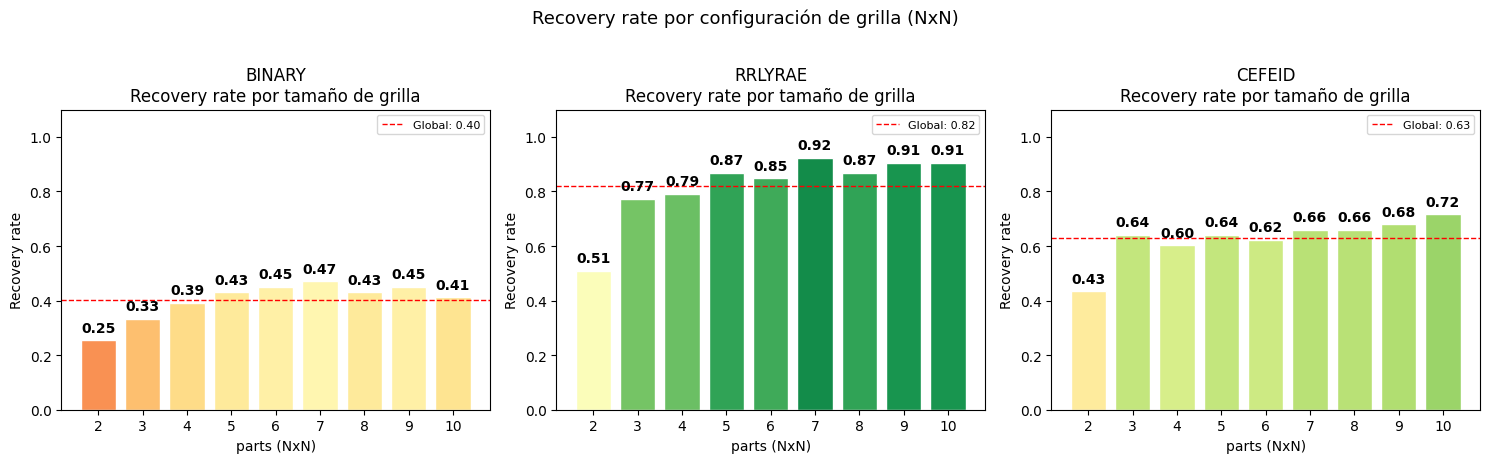

Gráfico guardado en: resultados_masivos/grilla_heatmap_20260424_062426.png


In [5]:
# ── Gráfico de recovery rate por parts y tipo ─────────────────────────────────
n_tipos = len(ACTIVE_TYPES)
fig, axes = plt.subplots(1, n_tipos, figsize=(5 * n_tipos, 4.5))
if n_tipos == 1:
    axes = [axes]

cmap = plt.cm.RdYlGn

for ax, tipo in zip(axes, ACTIVE_TYPES):
    df_tipo  = df_results[df_results["tipo"] == tipo]
    recovery = df_tipo.groupby("parts")["success"].mean()

    colors = [cmap(v) for v in recovery.values]
    bars   = ax.bar(recovery.index.astype(str), recovery.values, color=colors, edgecolor="white")

    # Anotar valor encima de cada barra
    for bar, val in zip(bars, recovery.values):
        text_color = "black" if 0.25 < val < 0.85 else "white"
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                f"{val:.2f}", ha="center", va="bottom",
                fontsize=10, fontweight="bold", color="black")

    ax.set_ylim(0, 1.1)
    ax.set_xlabel("parts (NxN)")
    ax.set_ylabel("Recovery rate")
    ax.set_title(f"{tipo.upper()}\nRecovery rate por tamaño de grilla")
    ax.axhline(df_tipo["success"].mean(), color="red", linestyle="--",
               linewidth=1, label=f"Global: {df_tipo['success'].mean():.2f}")
    ax.legend(fontsize=8)

plt.suptitle("Recovery rate por configuración de grilla (NxN)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"resultados_masivos/grilla_heatmap_{timestamp}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Gráfico guardado en: resultados_masivos/grilla_heatmap_{timestamp}.png")

In [6]:
# ── Resumen: mejores configuraciones por tipo ─────────────────────────────────
print("Mejores configuraciones por tipo:\n")
for tipo in ACTIVE_TYPES:
    df_tipo = df_results[df_results["tipo"] == tipo]
    ranking = (
        df_tipo.groupby("parts")["success"]
        .mean()
        .rename("recovery_rate")
        .reset_index()
        .sort_values("recovery_rate", ascending=False)
    )
    ranking["grilla"] = ranking["parts"].astype(str) + "x" + ranking["parts"].astype(str)
    print(f"  {tipo.upper()}:")
    print(ranking[["grilla", "recovery_rate"]].to_string(index=False))
    print()

Mejores configuraciones por tipo:

  BINARY:
grilla  recovery_rate
   7x7       0.470588
   9x9       0.450980
   6x6       0.450980
   8x8       0.431373
   5x5       0.431373
 10x10       0.411765
   4x4       0.392157
   3x3       0.333333
   2x2       0.254902

  RRLYRAE:
grilla  recovery_rate
   7x7       0.924528
 10x10       0.905660
   9x9       0.905660
   8x8       0.867925
   5x5       0.867925
   6x6       0.849057
   4x4       0.792453
   3x3       0.773585
   2x2       0.509434

  CEFEID:
grilla  recovery_rate
 10x10       0.716981
   9x9       0.679245
   7x7       0.660377
   8x8       0.660377
   5x5       0.641509
   3x3       0.641509
   6x6       0.622642
   4x4       0.603774
   2x2       0.433962

